# Final Architecture Results — Phase 4 & Best Models

**Focus:** Phase 4 hybrid architecture outcomes + overall best models across all research phases.

Condensed analysis notebook (complementary to `results_analysis.ipynb`).

## 1. Setup & Data Loading

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

import wandb

# Sync W&B offline runs (optional)
print("Syncing W&B offline runs...")
import subprocess
try:
    subprocess.run(["wandb", "sync", "--sync-all"], capture_output=True, timeout=30)
    print("✓ W&B sync complete")
except Exception as e:
    print(f"⚠ W&B sync skipped: {e}")

project_root = Path.cwd().parent

PHASE4_DIR = project_root / "results" / "final_architecture_phase4"
ALL_PHASES_DIRS = {
    "Phase 1": project_root / "results" / "baselines_qat_phase1",
    "Phase 2": project_root / "results" / "alexnet_qat_phase2",
    "Phase 3": project_root / "results" / "compensation_phase3",
    "Phase 4": PHASE4_DIR,
}

FIGURES_DIR = project_root / "results" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"font.size": 11})
print("✓ Setup complete")

Syncing W&B offline runs...
⚠ W&B sync skipped: Command '['wandb', 'sync', '--sync-all']' timed out after 30 seconds
✓ Setup complete


In [2]:
# Load Phase 4 comparison table
phase4_comp = pd.read_csv(PHASE4_DIR / "final_comparison.csv")
phase4_comp["phase"] = "Phase 4"

# Load all cross-phase comparisons
all_comps = [phase4_comp]
for phase_name, phase_dir in list(ALL_PHASES_DIRS.items())[:-1]:  # Skip Phase 4, already loaded
    csv_path = phase_dir / "final_comparison.csv"
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        df["phase"] = phase_name
        all_comps.append(df)

df_all = pd.concat(all_comps, ignore_index=True)

# Load per-model summaries (Phase 4 only for now)
phase4_summaries = {}
for json_file in sorted(PHASE4_DIR.glob("*_summary.json")):
    if json_file.name != "experiment_summary.json":
        with open(json_file) as f:
            phase4_summaries[json_file.stem] = json.load(f)

print(f"✓ Loaded Phase 4: {len(phase4_comp)} models")
print(f"✓ Loaded all phases: {len(df_all)} model variants")
print(f"✓ Loaded Phase 4 summaries: {len(phase4_summaries)} models")

✓ Loaded Phase 4: 8 models
✓ Loaded all phases: 41 model variants
✓ Loaded Phase 4 summaries: 4 models


## 2. Phase 4 Summary Table

In [3]:
print("Phase 4 — Final Architecture Models (FP32 & INT8 Quantization)")
print("="*80)

phase4_display = phase4_comp[["model", "precision", "top1_%", "top5_%", "loss", "params_M", "size_MB"]].copy()
phase4_display = phase4_display.sort_values(["precision", "top1_%"], ascending=[False, False])

display(phase4_display.reset_index(drop=True))

print("\n📊 Phase 4 Best Models:")
fp32_best = phase4_comp[phase4_comp["precision"] == "FP32"].nlargest(1, "top1_%")
int8_best = phase4_comp[phase4_comp["precision"] == "INT8"].nlargest(1, "top1_%")

if not fp32_best.empty:
    row = fp32_best.iloc[0]
    print(f"  FP32 Best: {row['model']:40s} | {row['top1_%']:6.2f}% top-1 | {row['size_MB']:6.2f} MB")

if not int8_best.empty:
    row = int8_best.iloc[0]
    print(f"  INT8 Best: {row['model']:40s} | {row['top1_%']:6.2f}% top-1 | {row['size_MB']:6.2f} MB")

Phase 4 — Final Architecture Models (FP32 & INT8 Quantization)


,model,precision,top1_%,top5_%,loss,params_M,size_MB
0,alexnet_final_fire_residual_INT8,INT8,49.201027,74.387586,2.153559,0.698664,0.746309
1,alexnet_final_bottleneck_residual_INT8,INT8,45.980674,72.328943,2.280574,0.571304,0.637690
2,alexnet_final_bottleneck_fire_INT8,INT8,44.001037,70.151949,2.381651,0.506408,0.545216
3,alexnet_final_depthwise_fire_INT8,INT8,42.789248,68.953073,2.452214,0.474921,0.509390
4,alexnet_final_fire_residual,FP32,49.793291,74.802184,2.131824,0.698664,8.093657
5,alexnet_final_bottleneck_residual,FP32,45.099601,71.151185,2.338797,0.571304,6.653960
6,alexnet_final_depthwise_fire,FP32,43.455875,69.023257,2.443448,0.474921,5.511263
7,alexnet_final_bottleneck_fire,FP32,42.286080,68.539512,2.490701,0.506408,5.882781



📊 Phase 4 Best Models:
  FP32 Best: alexnet_final_fire_residual              |  49.79% top-1 |   8.09 MB
  INT8 Best: alexnet_final_fire_residual_INT8         |  49.20% top-1 |   0.75 MB


## 3. Phase 4 Visualizations

### 3.1 FP32 vs INT8 Quantization Impact

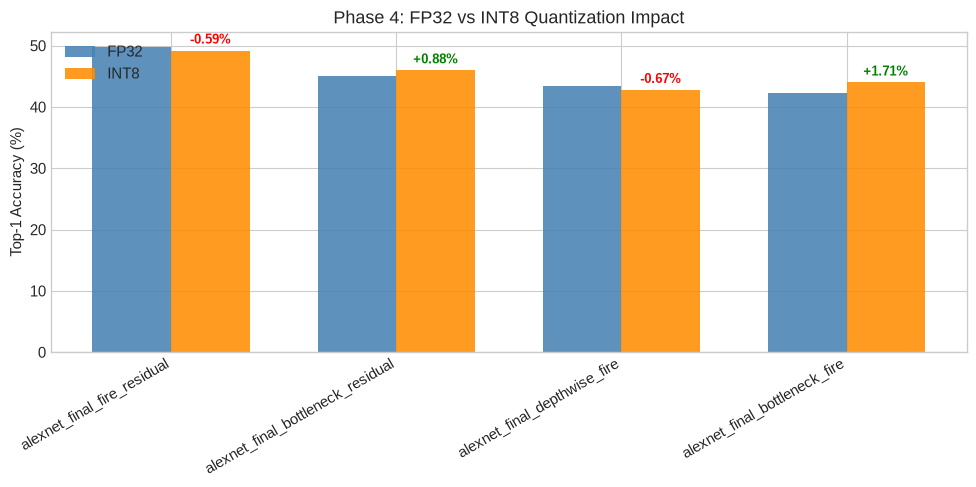

✓ Saved phase4_fp32_vs_int8.png


In [4]:
# Prepare Phase 4 quantization comparison
_df = phase4_comp.copy()
_df["base_model"] = _df["model"].str.replace("_INT8", "", regex=False)

has_both = _df.groupby("base_model")["precision"].apply(
    lambda x: {"FP32", "INT8"}.issubset(set(x))
)
paired = has_both[has_both].index.tolist()

if paired:
    df_paired = _df[_df["base_model"].isin(paired)].copy()
    df_pivot = (
        df_paired
        .pivot_table(index="base_model", columns="precision", values="top1_%")
        .reset_index()
    )
    df_pivot["drop"] = df_pivot["FP32"] - df_pivot["INT8"]
    df_pivot = df_pivot.sort_values("FP32", ascending=False).reset_index(drop=True)

    x = np.arange(len(df_pivot))
    w = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - w/2, df_pivot["FP32"], w, label="FP32", color="steelblue", alpha=0.87)
    ax.bar(x + w/2, df_pivot["INT8"], w, label="INT8", color="darkorange", alpha=0.87)

    for i, row in df_pivot.iterrows():
        color = "red" if row["drop"] > 0.5 else "green" if row["drop"] < 0 else "gray"
        sign = "-" if row["drop"] > 0 else "+"
        ax.annotate(
            f"{sign}{abs(row['drop']):.2f}%",
            xy=(x[i] + w/2, row["INT8"]),
            xytext=(0, 5), textcoords="offset points",
            ha="center", fontsize=9, color=color, fontweight="bold",
        )

    ax.set_xticks(x)
    ax.set_xticklabels(df_pivot["base_model"], rotation=30, ha="right")
    ax.set_ylabel("Top-1 Accuracy (%)")
    ax.set_title("Phase 4: FP32 vs INT8 Quantization Impact")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "phase4_fp32_vs_int8.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Saved phase4_fp32_vs_int8.png")

### 3.2 Phase 4 Model Efficiency

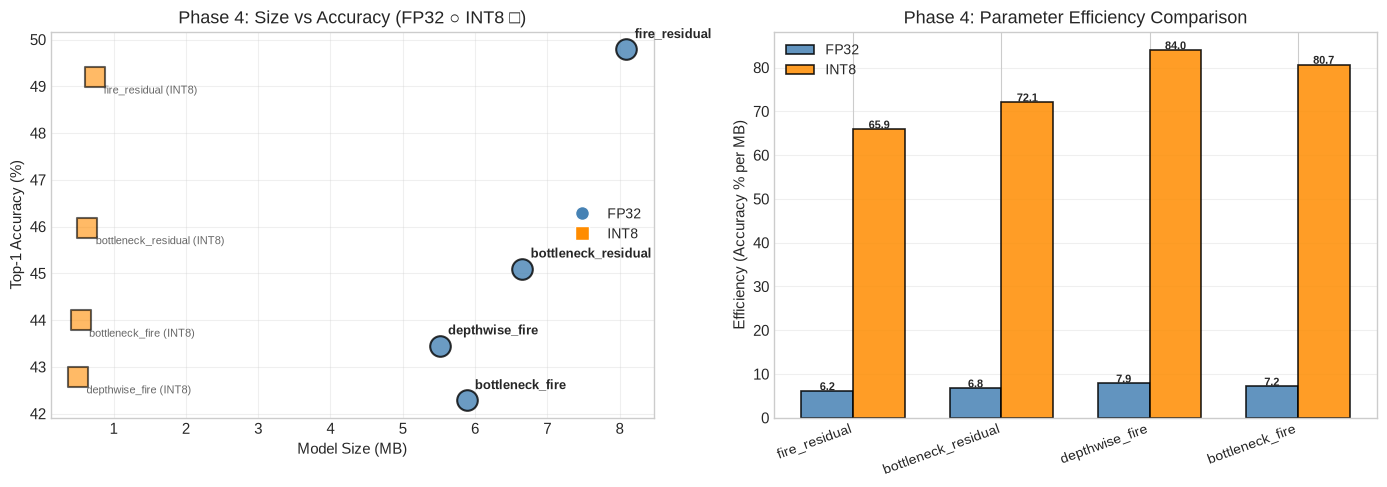

✓ Saved phase4_efficiency.png (FP32 + INT8 comparison)


In [5]:
# Efficiency: accuracy per MB — FP32 vs INT8 comparison
phase4_fp32 = phase4_comp[phase4_comp["precision"] == "FP32"].copy()
phase4_int8 = phase4_comp[phase4_comp["precision"] == "INT8"].copy()

phase4_fp32["efficiency"] = phase4_fp32["top1_%"] / phase4_fp32["size_MB"]
phase4_int8["efficiency"] = phase4_int8["top1_%"] / phase4_int8["size_MB"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: Scatter plot — Size vs Accuracy (FP32 circles, INT8 squares)
for idx, row in phase4_fp32.iterrows():
    ax1.scatter(row["size_MB"], row["top1_%"], s=220, alpha=0.8, 
               edgecolors="black", lw=1.5, color="steelblue", zorder=3)
    model_label = row["model"].replace("alexnet_final_", "")
    ax1.annotate(model_label, 
                 (row["size_MB"], row["top1_%"]),
                 xytext=(6, 8), textcoords="offset points", fontsize=9, fontweight="bold")

for idx, row in phase4_int8.iterrows():
    ax1.scatter(row["size_MB"], row["top1_%"], s=220, alpha=0.6, marker="s",
               edgecolors="black", lw=1.5, color="darkorange", zorder=3)
    model_label = row["model"].replace("_INT8", "").replace("alexnet_final_", "")
    ax1.annotate(f"{model_label} (INT8)", 
                 (row["size_MB"], row["top1_%"]),
                 xytext=(6, -12), textcoords="offset points", fontsize=8, alpha=0.7)

# Add legend patch
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue", markersize=10, label="FP32"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="darkorange", markersize=10, label="INT8"),
]
ax1.legend(handles=legend_elements, loc="best", fontsize=10)
ax1.set_xlabel("Model Size (MB)")
ax1.set_ylabel("Top-1 Accuracy (%)")
ax1.set_title("Phase 4: Size vs Accuracy (FP32 ○ INT8 □)")
ax1.grid(True, alpha=0.3)

# RIGHT: Bar chart — Efficiency comparison
model_names = phase4_fp32["model"].str.replace("alexnet_final_", "").values
fp32_effs = phase4_fp32["efficiency"].values

# Match INT8 to FP32 for comparison
int8_effs = []
for fp32_model in phase4_fp32["model"]:
    int8_model = fp32_model + "_INT8"
    match = phase4_int8[phase4_int8["model"] == int8_model]
    if not match.empty:
        int8_effs.append(match.iloc[0]["efficiency"])
    else:
        int8_effs.append(0)

x = np.arange(len(model_names))
w = 0.35

ax2.bar(x - w/2, fp32_effs, w, label="FP32", color="steelblue", alpha=0.85, edgecolor="black", lw=1.2)
ax2.bar(x + w/2, int8_effs, w, label="INT8", color="darkorange", alpha=0.85, edgecolor="black", lw=1.2)

# Add value labels
for i, (fp32, int8) in enumerate(zip(fp32_effs, int8_effs)):
    ax2.text(i - w/2, fp32 + 0.15, f"{fp32:.1f}", ha="center", fontsize=8, fontweight="bold")
    if int8 > 0:
        ax2.text(i + w/2, int8 + 0.15, f"{int8:.1f}", ha="center", fontsize=8, fontweight="bold")

ax2.set_xticks(x)
ax2.set_xticklabels(model_names, rotation=20, ha="right", fontsize=10)
ax2.set_ylabel("Efficiency (Accuracy % per MB)")
ax2.set_title("Phase 4: Parameter Efficiency Comparison")
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase4_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Saved phase4_efficiency.png (FP32 + INT8 comparison)")

### 3.3 Phase 4 Ablation Summary


📈 Phase 4 Ablation: Hybrid vs Single-Mechanism Parents


,Hybrid Model,Parents,Hybrid Top-1 %,Best Parent Top-1 %,Delta %
0,alexnet_final_bottleneck_fire,Bottleneck + Fire,42.286080,44.622979,-2.336898
1,alexnet_final_fire_residual,Fire + Residual,49.793291,48.012939,1.780352
2,alexnet_final_bottleneck_residual,Bottleneck + Residual,45.099601,48.012939,-2.913338
3,alexnet_final_depthwise_fire,Depthwise-Sep + Fire,43.455875,44.390011,-0.934136


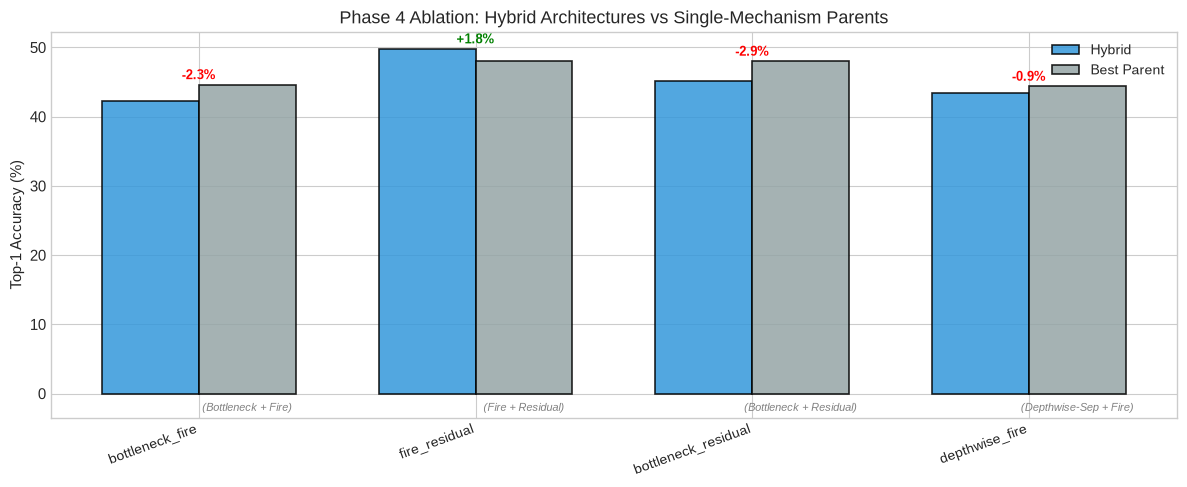

✓ Saved phase4_ablation.png (with parent specifications)


In [6]:
# Load Phase 4 ablation results
ablation_path = PHASE4_DIR / "ablation_results.csv"
if ablation_path.exists():
    ablation = pd.read_csv(ablation_path)
    
    print("\n📈 Phase 4 Ablation: Hybrid vs Single-Mechanism Parents")
    print("="*80)
    
    # Map hybrids to their parents for display
    parent_map = {
        "alexnet_final_bottleneck_fire": ["Bottleneck", "Fire"],
        "alexnet_final_fire_residual": ["Fire", "Residual"],
        "alexnet_final_bottleneck_residual": ["Bottleneck", "Residual"],
        "alexnet_final_depthwise_fire": ["Depthwise-Sep", "Fire"],
    }
    
    display_cols = ["hybrid", "hybrid_top1", "best_parent_top1", "delta_vs_best_parent"]
    ablation_display = ablation[[c for c in display_cols if c in ablation.columns]].copy()
    ablation_display.columns = ["Hybrid Model", "Hybrid Top-1 %", "Best Parent Top-1 %", "Delta %"]
    
    # Add parent info
    ablation_display["Parents"] = ablation["hybrid"].map(lambda x: " + ".join(parent_map.get(x, ["Unknown"])))
    
    display(ablation_display[["Hybrid Model", "Parents", "Hybrid Top-1 %", "Best Parent Top-1 %", "Delta %"]])
    
    # Visualization with parent labels
    fig, ax = plt.subplots(figsize=(12, 5))
    
    x = np.arange(len(ablation))
    w = 0.35
    
    hybrid_names = ablation["hybrid"].str.replace("alexnet_final_", "").values
    ax.bar(x - w/2, ablation["hybrid_top1"], w, label="Hybrid", color="#3498db", alpha=0.85, edgecolor="black", lw=1.2)
    ax.bar(x + w/2, ablation["best_parent_top1"], w, label="Best Parent", color="#95a5a6", alpha=0.85, edgecolor="black", lw=1.2)
    
    # Annotations: delta + parent info
    for i, (idx, row) in enumerate(ablation.iterrows()):
        delta = row["delta_vs_best_parent"]
        color = "green" if delta > 0 else "red"
        sign = "+" if delta > 0 else ""
        
        # Parent names
        parents = parent_map.get(row["hybrid"], ["Unknown"])
        parent_label = " + ".join(parents)
        
        # Delta annotation
        ax.text(x[i], max(row["hybrid_top1"], row["best_parent_top1"]) + 0.8,
                f"{sign}{delta:.1f}%", ha="center", fontsize=9, color=color, fontweight="bold")
        
        # Parent label below x-axis
        ax.text(x[i] + w/2, -2.5, f"({parent_label})", ha="center", fontsize=8, 
               style="italic", color="gray", rotation=0)
    
    ax.set_xticks(x)
    ax.set_xticklabels(hybrid_names, rotation=20, ha="right", fontsize=10)
    ax.set_ylabel("Top-1 Accuracy (%)")
    ax.set_title("Phase 4 Ablation: Hybrid Architectures vs Single-Mechanism Parents")
    ax.set_ylim(bottom=-3.5)
    ax.legend(fontsize=10, loc="upper right")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "phase4_ablation.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Saved phase4_ablation.png (with parent specifications)")
else:
    print("[skip] ablation_results.csv not found")

## 4. Cross-Phase Best Models

In [7]:
# Top 10 models by FP32 accuracy across all phases
df_fp32_all = df_all[df_all["precision"] == "FP32"].copy()
top10 = df_fp32_all.nlargest(10, "top1_%")[["phase", "model", "top1_%", "top5_%", "params_M", "size_MB"]]

print("\n🏆 Top 10 Models — All Phases (FP32)")
print("="*80)
display(top10.reset_index(drop=True))

# Highlight Phase 4 in top 10
phase4_in_top10 = top10[top10["phase"] == "Phase 4"]
if not phase4_in_top10.empty:
    print(f"\n✓ Phase 4 models in top 10: {len(phase4_in_top10)}")
    for _, row in phase4_in_top10.iterrows():
        print(f"  • {row['model']:40s} | {row['top1_%']:6.2f}%")
else:
    print("\n⚠ No Phase 4 models in top 10 by accuracy")


🏆 Top 10 Models — All Phases (FP32)


,phase,model,top1_%,top5_%,params_M,size_MB
0,Phase 1,mobilenetv2,57.995582,81.514984,2.480072,28.751925
1,Phase 1,resnet18_tv,53.913635,77.797484,11.279112,129.208681
2,Phase 1,vgg_style,51.814806,75.881696,2.405288,27.584812
3,Phase 4,alexnet_final_fire_residual,49.793291,74.802184,0.698664,8.093657
4,Phase 3,alexnet_residual,48.012939,73.108339,60.670280,694.414034
5,Phase 2,alexnet_small_kernel,45.836565,71.076936,1.602376,18.353315
6,Phase 4,alexnet_final_bottleneck_residual,45.099601,71.151185,0.571304,6.653960
7,Phase 3,alexnet_bottleneck,44.622979,71.036339,0.385000,4.491745
8,Phase 2,alexnet_stacked,44.559684,70.791721,60.483976,692.254669
9,Phase 3,alexnet_depthwisesep,44.390011,69.445616,0.313641,3.654016



✓ Phase 4 models in top 10: 2
  • alexnet_final_fire_residual              |  49.79%
  • alexnet_final_bottleneck_residual        |  45.10%


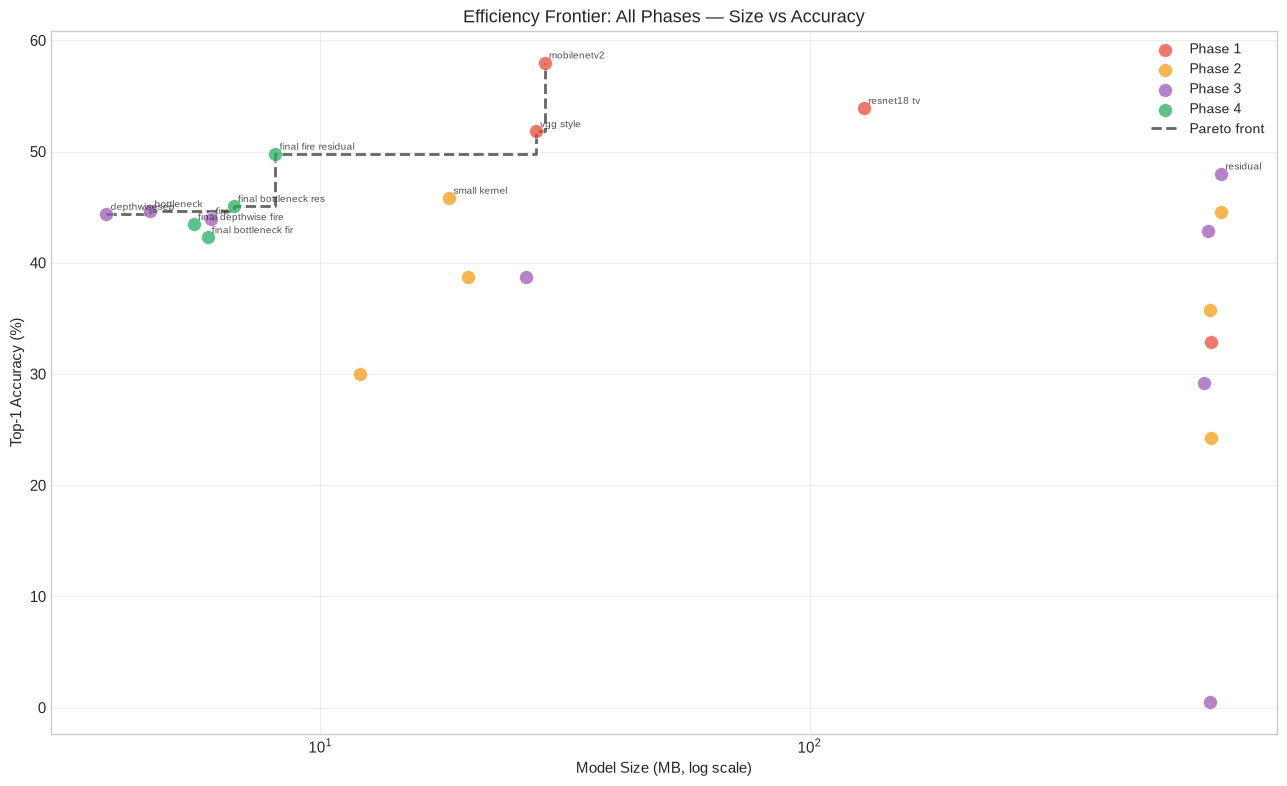

✓ Saved cross_phase_efficiency_frontier.png


In [8]:
# Cross-phase efficiency frontier
df_fp32_all["efficiency"] = df_fp32_all["top1_%"] / df_fp32_all["size_MB"]

def pareto_front_mask(xs, ys):
    """Boolean mask: True if point is Pareto-optimal (minimize x, maximize y)."""
    xs, ys = np.asarray(xs, float), np.asarray(ys, float)
    dominated = np.zeros(len(xs), dtype=bool)
    for i in range(len(xs)):
        for j in range(len(xs)):
            if i != j and xs[j] <= xs[i] and ys[j] >= ys[i] and (xs[j] < xs[i] or ys[j] > ys[i]):
                dominated[i] = True
                break
    return ~dominated

phase_colors = {"Phase 1": "#e74c3c", "Phase 2": "#f39c12", "Phase 3": "#9b59b6", "Phase 4": "#27ae60"}

fig, ax = plt.subplots(figsize=(13, 8))

# Plot all models by phase
for phase in ["Phase 1", "Phase 2", "Phase 3", "Phase 4"]:
    sub = df_fp32_all[df_fp32_all["phase"] == phase]
    if sub.empty:
        continue
    ax.scatter(sub["size_MB"], sub["top1_%"],
               c=phase_colors[phase], marker="o", s=100,
               label=phase, alpha=0.75, edgecolors="white", lw=0.5, zorder=3)

# Pareto front overlay
if len(df_fp32_all) >= 2:
    pf_mask = pareto_front_mask(df_fp32_all["size_MB"].values, df_fp32_all["top1_%"].values)
    pf = df_fp32_all[pf_mask].sort_values("size_MB")
    ax.step(pf["size_MB"], pf["top1_%"], where="post",
            color="black", lw=2, ls="--", alpha=0.6, label="Pareto front", zorder=2)

# Annotations for interesting models
for _, row in df_fp32_all.iterrows():
    if row["top1_%"] > 45 or (row["size_MB"] < 10 and row["top1_%"] > 40):
        label = row["model"].replace("alexnet_", "").replace("_", " ")[:20]
        ax.annotate(label, (row["size_MB"], row["top1_%"]),
                    xytext=(3, 3), textcoords="offset points", fontsize=7.5, alpha=0.8)

ax.set_xscale("log")
ax.set_xlabel("Model Size (MB, log scale)")
ax.set_ylabel("Top-1 Accuracy (%)")
ax.set_title("Efficiency Frontier: All Phases — Size vs Accuracy")
ax.legend(loc="best", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cross_phase_efficiency_frontier.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Saved cross_phase_efficiency_frontier.png")

## 5. Key Findings & Recommendations

In [9]:
print("\n" + "="*80)
print("RESEARCH HIGHLIGHTS")
print("="*80)

# Best overall (all phases)
best_overall = df_fp32_all.nlargest(1, "top1_%").iloc[0]
print(f"\n🥇 Best Overall Accuracy (All Phases):")
print(f"   {best_overall['model']:40s} [{best_overall['phase']}]")
print(f"   Top-1: {best_overall['top1_%']:.2f}%  |  Params: {best_overall['params_M']:.2f}M  |  Size: {best_overall['size_MB']:.2f} MB")

# Best tiny model (<10 MB)
tiny = df_fp32_all[df_fp32_all["size_MB"] < 10].nlargest(1, "top1_%")
if not tiny.empty:
    row = tiny.iloc[0]
    print(f"\n💎 Best Tiny Model (<10 MB):")
    print(f"   {row['model']:40s} [{row['phase']}]")
    print(f"   Top-1: {row['top1_%']:.2f}%  |  Size: {row['size_MB']:.2f} MB  |  Efficiency: {row['top1_%'] / row['size_MB']:.2f} acc/MB")

# Best efficient (acc/MB)
best_eff = df_fp32_all.copy()
best_eff["eff"] = best_eff["top1_%"] / best_eff["size_MB"]
best_efficient = best_eff.nlargest(1, "eff").iloc[0]
print(f"\n⚡ Most Efficient (Accuracy per MB):")
print(f"   {best_efficient['model']:40s} [{best_efficient['phase']}]")
print(f"   Top-1: {best_efficient['top1_%']:.2f}%  |  Size: {best_efficient['size_MB']:.2f} MB  |  Efficiency: {best_efficient['eff']:.2f} acc/MB")

# Phase 4 summary
print(f"\n📊 Phase 4 Summary:")
print(f"   Models: 4 hybrid architectures")
print(f"   Best FP32: {phase4_fp32.nlargest(1, 'top1_%').iloc[0]['model']:35s} | {phase4_fp32['top1_%'].max():.2f}%")
phase4_int8 = phase4_comp[phase4_comp["precision"] == "INT8"]
if not phase4_int8.empty:
    print(f"   Best INT8: {phase4_int8.nlargest(1, 'top1_%').iloc[0]['model']:35s} | {phase4_int8['top1_%'].max():.2f}%")
    avg_drop = (phase4_fp32['top1_%'].mean() - phase4_int8['top1_%'].mean())
    print(f"   Avg QAT drop: {avg_drop:.2f}% (INT8 quantization robustness)")

print("\n" + "="*80)


RESEARCH HIGHLIGHTS

🥇 Best Overall Accuracy (All Phases):
   mobilenetv2                              [Phase 1]
   Top-1: 58.00%  |  Params: 2.48M  |  Size: 28.75 MB

💎 Best Tiny Model (<10 MB):
   alexnet_final_fire_residual              [Phase 4]
   Top-1: 49.79%  |  Size: 8.09 MB  |  Efficiency: 6.15 acc/MB

⚡ Most Efficient (Accuracy per MB):
   alexnet_depthwisesep                     [Phase 3]
   Top-1: 44.39%  |  Size: 3.65 MB  |  Efficiency: 12.15 acc/MB

📊 Phase 4 Summary:
   Models: 4 hybrid architectures
   Best FP32: alexnet_final_fire_residual         | 49.79%
   Best INT8: alexnet_final_fire_residual_INT8    | 49.20%
   Avg QAT drop: -0.33% (INT8 quantization robustness)



## 6. Export Summary Tables

In [10]:
# Phase 4 + Best models comparison export
summary_export = pd.DataFrame([
    {"category": "Phase 4 Best (FP32)", "model": best_overall["model"], "phase": best_overall["phase"],
     "top1_%": best_overall["top1_%"], "size_MB": best_overall["size_MB"], "params_M": best_overall["params_M"]},
])

if not tiny.empty:
    row = tiny.iloc[0]
    summary_export = pd.concat([
        summary_export,
        pd.DataFrame([{"category": "Best Tiny (<10MB)", "model": row["model"], "phase": row["phase"],
                      "top1_%": row["top1_%"], "size_MB": row["size_MB"], "params_M": row["params_M"]}])
    ], ignore_index=True)

summary_export = pd.concat([
    summary_export,
    pd.DataFrame([{"category": "Most Efficient", "model": best_efficient["model"], "phase": best_efficient["phase"],
                  "top1_%": best_efficient["top1_%"], "size_MB": best_efficient["size_MB"], "params_M": best_efficient["params_M"]}])
], ignore_index=True)

summary_export.to_csv(project_root / "results" / "phase4_best_models.csv", index=False)
print(f"✓ Exported phase4_best_models.csv")
display(summary_export)

✓ Exported phase4_best_models.csv


,category,model,phase,top1_%,size_MB,params_M
0,Phase 4 Best (FP32),mobilenetv2,Phase 1,57.995582,28.751925,2.480072
1,Best Tiny (<10MB),alexnet_final_fire_residual,Phase 4,49.793291,8.093657,0.698664
2,Most Efficient,alexnet_depthwisesep,Phase 3,44.390011,3.654016,0.313641


## 7. Compression Phase 4.1 Results

In [11]:
# Load compression results (5 models × 4 methods: int8, int4_ptq, int4_qat, mixed)
COMPRESSION_DIR = project_root / "results" / "compression_phase4_1"

comp_df = pd.read_csv(COMPRESSION_DIR / "final_comparison.csv")
comp_by_method = pd.read_csv(COMPRESSION_DIR / "compression_by_method.csv")
comp_pareto = pd.read_csv(COMPRESSION_DIR / "pareto_frontier.csv")

print(f"✓ Loaded compression results from {COMPRESSION_DIR.name}")
print(f"  {len(comp_df)} runs = {comp_df['model'].nunique()} models × {comp_df['method'].nunique()} methods")
print(f"  Methods: {', '.join(sorted(comp_df['method'].unique()))}")
print(f"  Pareto frontier: {len(comp_pareto)} optimal points")

✓ Loaded compression results from compression_phase4_1
  16 runs = 5 models × 4 methods
  Methods: int4_ptq, int4_qat, int8, mixed
  Pareto frontier: 9 optimal points


In [12]:
# Compression matrix — every model × method run
print("\n📦 Compression Phase 4.1 — Model × Method Matrix")
print("="*100)

cols = ["model", "method", "precision", "fp32_baseline_acc", "compressed_top1_acc",
        "acc_drop_pp", "compression_ratio", "compressed_size_mb", "acc_per_mb"]
tbl = comp_df[cols].sort_values(["model", "acc_per_mb"], ascending=[True, False]).copy()
tbl.columns = ["Model", "Method", "Precision", "FP32 Acc %", "Compressed Acc %",
               "Drop pp", "Compression×", "Size MB", "Acc/MB"]
display(tbl.round(2).reset_index(drop=True))

# Best method per model, by accuracy-per-MB
print("\n🏆 Best method per model (by accuracy-per-MB):")
best = comp_df.loc[comp_df.groupby("model")["acc_per_mb"].idxmax()]
for _, r in best.sort_values("acc_per_mb", ascending=False).iterrows():
    print(f"  {r['model']:30s} | {r['method']:9s} | {r['compressed_top1_acc']:5.2f}% "
          f"| {r['compression_ratio']:4.1f}× | {r['acc_per_mb']:6.1f} acc/MB")


📦 Compression Phase 4.1 — Model × Method Matrix


,Model,Method,Precision,FP32 Acc %,Compressed Acc %,Drop pp,Compression×,Size MB,Acc/MB
0,alexnet_bottleneck,int4_qat,int4,44.62,44.34,0.29,7.87,0.19,239.20
1,alexnet_bottleneck,mixed,int4/8,44.62,44.61,0.01,6.95,0.21,212.53
2,alexnet_bottleneck,int4_ptq,int4,44.62,35.32,9.30,7.87,0.19,190.58
3,alexnet_bottleneck,int8,int8,44.62,44.24,0.39,3.97,0.37,120.48
4,alexnet_depthwisesep,mixed,int4/8,44.39,44.27,0.12,7.50,0.16,280.48
5,alexnet_depthwisesep,int4_qat,int4,44.39,41.32,3.07,7.81,0.15,272.58
6,alexnet_depthwisesep,int8,int8,44.39,43.65,0.74,3.96,0.30,145.95
7,alexnet_depthwisesep,int4_ptq,int4,44.39,10.00,34.39,7.81,0.15,65.94
8,alexnet_final_fire_residual,int4_ptq,int4,49.79,40.01,9.78,7.91,0.34,119.30
9,alexnet_final_fire_residual,int8,int8,49.79,49.76,0.04,3.98,0.67,74.68



🏆 Best method per model (by accuracy-per-MB):
  alexnet_depthwisesep           | mixed     | 44.27% |  7.5× |  280.5 acc/MB
  alexnet_bottleneck             | int4_qat  | 44.34% |  7.9× |  239.2 acc/MB
  alexnet_fire                   | int4_qat  | 44.26% |  7.9× |  178.7 acc/MB
  alexnet_final_fire_residual    | int4_ptq  | 40.01% |  7.9× |  119.3 acc/MB
  mobilenetv2                    | int8      | 55.41% |  4.0× |   23.4 acc/MB


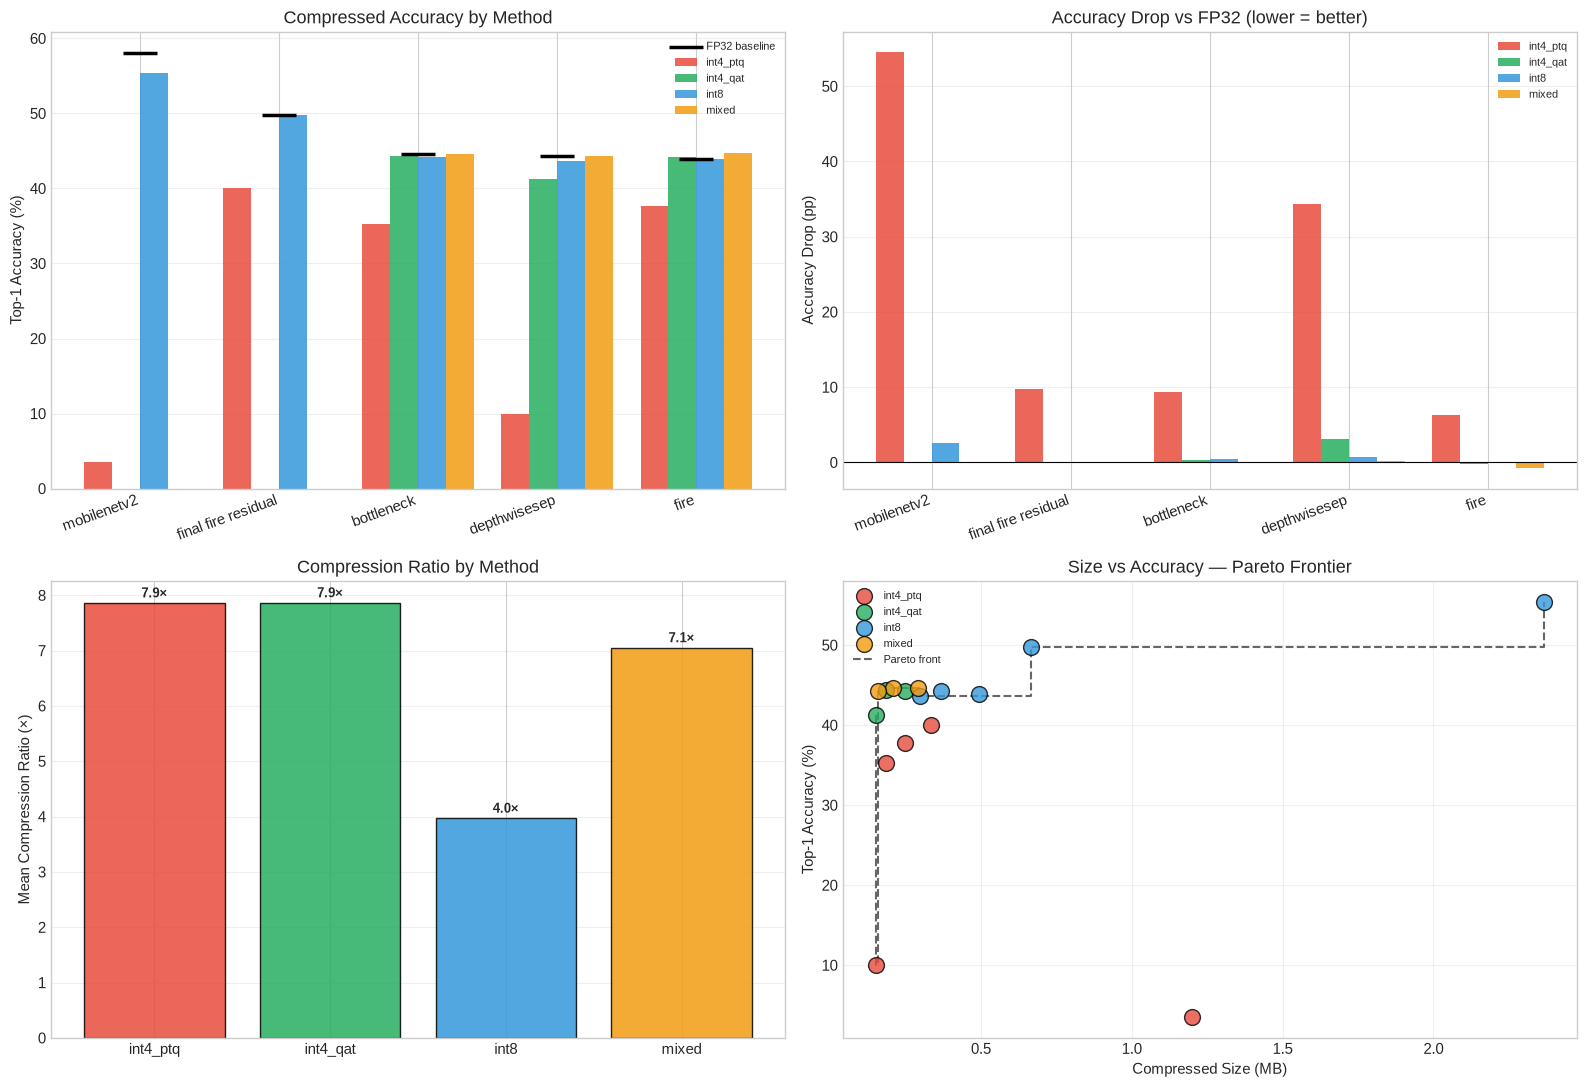

✓ Saved compression_phase4_1_impact.png


In [13]:
# Compression impact visualization (2×2)
methods = sorted(comp_df["method"].unique())
method_colors = {"int8": "#3498db", "int4_ptq": "#e74c3c", "int4_qat": "#27ae60", "mixed": "#f39c12"}
# Order models by FP32 baseline accuracy (descending)
models = (comp_df.groupby("model")["fp32_baseline_acc"].first()
          .sort_values(ascending=False).index.tolist())
short = lambda m: m.replace("alexnet_", "").replace("_", " ")

x = np.arange(len(models))
w = 0.8 / len(methods)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1. Compressed accuracy by model & method (FP32 baseline as markers)
ax = axes[0, 0]
acc_piv = comp_df.pivot_table(index="model", columns="method", values="compressed_top1_acc").reindex(models)[methods]
for i, meth in enumerate(methods):
    ax.bar(x + i*w - 0.4 + w/2, acc_piv[meth], w, label=meth, color=method_colors.get(meth), alpha=0.85)
base = comp_df.groupby("model")["fp32_baseline_acc"].first().reindex(models)
ax.scatter(x, base, marker="_", s=600, color="black", lw=2.5, zorder=5, label="FP32 baseline")
ax.set_xticks(x); ax.set_xticklabels([short(m) for m in models], rotation=20, ha="right")
ax.set_ylabel("Top-1 Accuracy (%)"); ax.set_title("Compressed Accuracy by Method")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis="y")

# 2. Accuracy drop by model & method (lower = better; negative = improved)
ax = axes[0, 1]
drop_piv = comp_df.pivot_table(index="model", columns="method", values="acc_drop_pp").reindex(models)[methods]
for i, meth in enumerate(methods):
    ax.bar(x + i*w - 0.4 + w/2, drop_piv[meth], w, label=meth, color=method_colors.get(meth), alpha=0.85)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels([short(m) for m in models], rotation=20, ha="right")
ax.set_ylabel("Accuracy Drop (pp)"); ax.set_title("Accuracy Drop vs FP32 (lower = better)")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis="y")

# 3. Mean compression ratio by method
ax = axes[1, 0]
ax.bar(comp_by_method["method"], comp_by_method["mean_ratio"],
       color=[method_colors.get(m) for m in comp_by_method["method"]], alpha=0.85, edgecolor="black", lw=1)
for i, r in comp_by_method.reset_index(drop=True).iterrows():
    ax.text(i, r["mean_ratio"] + 0.1, f"{r['mean_ratio']:.1f}×", ha="center", fontweight="bold", fontsize=9)
ax.set_ylabel("Mean Compression Ratio (×)"); ax.set_title("Compression Ratio by Method")
ax.grid(True, alpha=0.3, axis="y")

# 4. Size vs accuracy — Pareto frontier
ax = axes[1, 1]
for meth in methods:
    sub = comp_df[comp_df["method"] == meth]
    ax.scatter(sub["compressed_size_mb"], sub["compressed_top1_acc"], s=130, alpha=0.8,
               color=method_colors.get(meth), edgecolors="black", lw=1, label=meth, zorder=3)
pf = comp_pareto.sort_values("compressed_size_mb")
ax.step(pf["compressed_size_mb"], pf["compressed_top1_acc"], where="post",
        color="black", ls="--", lw=1.5, alpha=0.6, label="Pareto front", zorder=2)
ax.set_xlabel("Compressed Size (MB)"); ax.set_ylabel("Top-1 Accuracy (%)")
ax.set_title("Size vs Accuracy — Pareto Frontier"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "compression_phase4_1_impact.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved compression_phase4_1_impact.png")


📊 Compression Methods Breakdown (mean across models)


,Method,Mean Top-1 %,Mean Drop pp,Mean Ratio ×,Mean Acc/MB,N models
0,int4_ptq,25.31,22.85,7.86,106.21,5
1,int4_qat,43.31,1.02,7.86,230.17,3
2,int8,47.40,0.76,3.97,90.76,5
3,mixed,44.52,-0.19,7.05,215.31,3


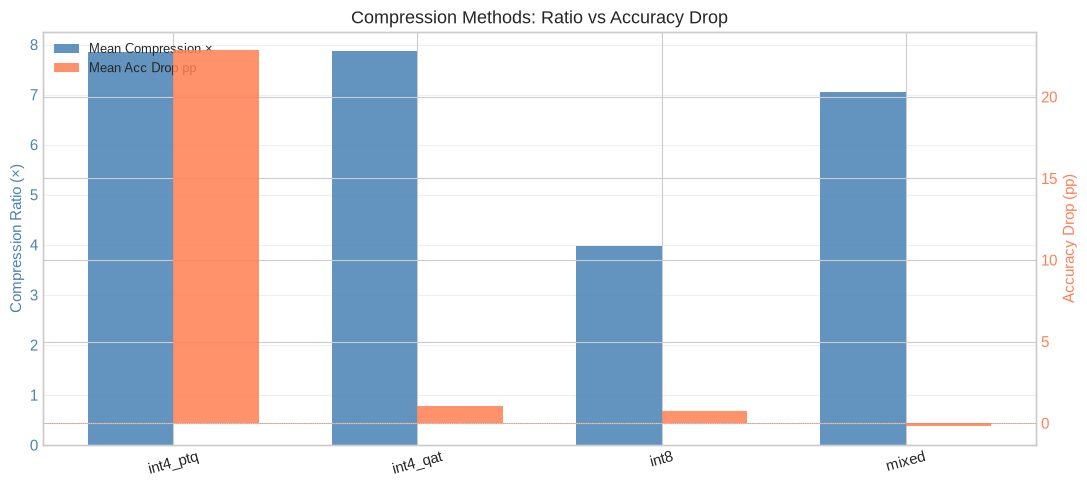

✓ Saved compression_methods_breakdown.png


In [14]:
# Compression methods breakdown (aggregated across models)
print("\n📊 Compression Methods Breakdown (mean across models)")
print("="*100)
disp = comp_by_method.copy()
disp.columns = ["Method", "Mean Top-1 %", "Mean Drop pp", "Mean Ratio ×", "Mean Acc/MB", "N models"]
display(disp.round(2))

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(comp_by_method)); w = 0.35
ax2 = ax.twinx()
b1 = ax.bar(x - w/2, comp_by_method["mean_ratio"], w, color="steelblue", alpha=0.85, label="Mean Compression ×")
b2 = ax2.bar(x + w/2, comp_by_method["mean_drop_pp"], w, color="coral", alpha=0.85, label="Mean Acc Drop pp")

ax.set_xticks(x); ax.set_xticklabels(comp_by_method["method"], rotation=15)
ax.set_ylabel("Compression Ratio (×)", color="steelblue")
ax2.set_ylabel("Accuracy Drop (pp)", color="coral")
ax.tick_params(axis="y", labelcolor="steelblue"); ax2.tick_params(axis="y", labelcolor="coral")
ax2.axhline(0, color="coral", lw=0.6, ls=":")
ax.set_title("Compression Methods: Ratio vs Accuracy Drop")
ax.grid(True, alpha=0.3, axis="y")
ax.legend(handles=[b1, b2], loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "compression_methods_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved compression_methods_breakdown.png")

### 7.4 Accuracy vs Size (Compression Trajectory)

/tmp/ipykernel_1570752/2625958137.py:37: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1570752/2625958137.py:38: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Liberation Sans.
  plt.savefig(FIGURES_DIR / "compression_phase4_1_accuracy_vs_size.png", dpi=150, bbox_inches="tight")
/home/rafael/Documents/alexnet_rafael/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


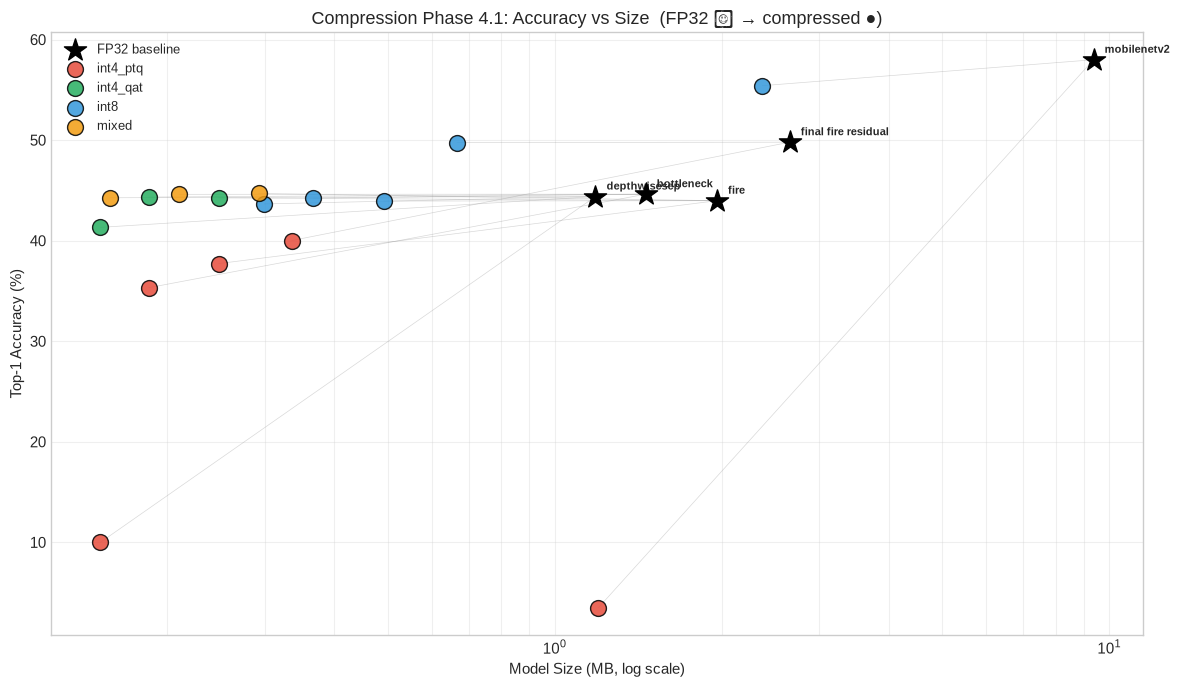

✓ Saved compression_phase4_1_accuracy_vs_size.png


In [15]:
# Accuracy vs Size — FP32 baselines → compressed variants
fig, ax = plt.subplots(figsize=(12, 7))

method_colors = {"int8": "#3498db", "int4_ptq": "#e74c3c", "int4_qat": "#27ae60", "mixed": "#f39c12"}
short = lambda m: m.replace("alexnet_", "").replace("_", " ")

# FP32 baseline (one point per model)
base = comp_df.groupby("model").agg(
    size=("fp32_size_mb", "first"), acc=("fp32_baseline_acc", "first")).reset_index()
base_map = base.set_index("model")

# Faint line from each FP32 baseline to its compressed variants (compression trajectory)
for _, r in comp_df.iterrows():
    b = base_map.loc[r["model"]]
    ax.plot([b["size"], r["compressed_size_mb"]], [b["acc"], r["compressed_top1_acc"]],
            color="gray", lw=0.5, alpha=0.3, zorder=1)

# FP32 baselines
ax.scatter(base["size"], base["acc"], s=280, marker="*", color="black", zorder=5, label="FP32 baseline")
for _, r in base.iterrows():
    ax.annotate(short(r["model"]), (r["size"], r["acc"]),
                xytext=(8, 5), textcoords="offset points", fontsize=8, fontweight="bold")

# Compressed variants, colored by method
for meth in sorted(comp_df["method"].unique()):
    sub = comp_df[comp_df["method"] == meth]
    ax.scatter(sub["compressed_size_mb"], sub["compressed_top1_acc"], s=130, alpha=0.85,
               color=method_colors.get(meth), edgecolors="black", lw=1, label=meth, zorder=3)

ax.set_xscale("log")
ax.set_xlabel("Model Size (MB, log scale)")
ax.set_ylabel("Top-1 Accuracy (%)")
ax.set_title("Compression Phase 4.1: Accuracy vs Size  (FP32 ★ → compressed ●)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "compression_phase4_1_accuracy_vs_size.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved compression_phase4_1_accuracy_vs_size.png")